# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `londono, simon`
- Apellido2, Nombre2: `serna, thomas`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [1]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1001371283
cedula2 = 1000100606

In [2]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 889
Parámetros — alpha: 1.00, beta: 2.60, gamma: 0.280, ruido: 0.100
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Sí, el spline va a pasar exactamente por cada valor de Z
data en la malla. La razon es que el splin no sabe que puntos son los de ruido y cuales no (osea se hace en todos los puntos).

b) si el ruido es muy significativo es conveninente para poder purgar nuestros datos, y ademas si se tiene conocimiento de que el modelo físico o matematico se comporta de cierta manera.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) Ai​=[1 ​xi ​​yi​​].

b) Como Ztrue no es un plano, el plano ajustado no representa exactamente la superficie real.
Representa la mejor aproximación plana global a los datos en el sentido de mínimos cuadrados. Es decir, el plano que minimiza la suma de errores cuadrados

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) busca indetificar las direeciones de máxima varianza en la nube de punto.
b) es la dirección en el espacio (x,y,z) a lo largo de la cual la nube de puntos presenta la mayor variación.

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [3]:
from scipy.interpolate import RectBivariateSpline
import numpy as np

# Construir spline bicúbico
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Malla fina 100x100 en [-3, 3] x [-3, 3]
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)

# Evaluar spline en la malla fina
Z_spline = spline(x_fine, y_fine)

print(f"x_fine shape: {x_fine.shape}")
print(f"y_fine shape: {y_fine.shape}")
print(f"Z_spline shape: {Z_spline.shape}")

x_fine shape: (100,)
y_fine shape: (100,)
Z_spline shape: (100, 100)


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

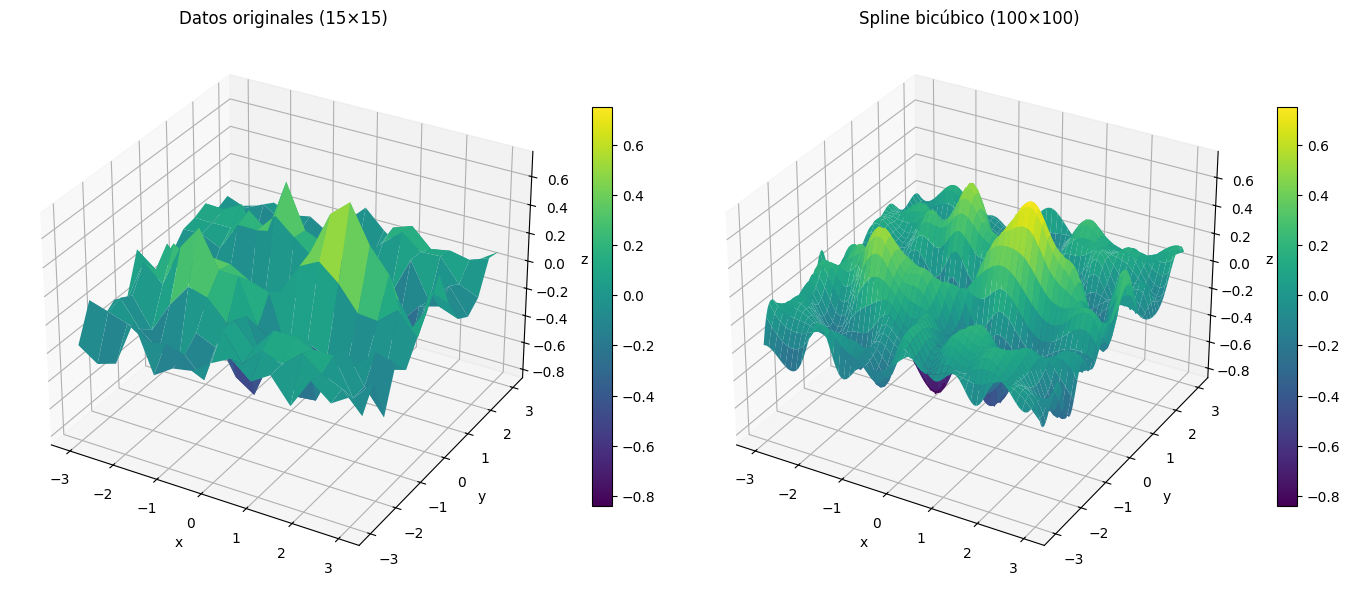

In [4]:
# TODO P2.2: figura comparativa datos vs spline
import numpy as np
import matplotlib.pyplot as plt

# Malla gruesa (15x15)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Malla fina (100x100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# Mismos límites de color para ambos paneles
vmin = min(np.min(Z_data), np.min(Z_spline))
vmax = max(np.max(Z_data), np.max(Z_spline))

fig = plt.figure(figsize=(14, 6))

# -------------------------
# Panel izquierdo: datos
# -------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surf1 = ax1.plot_surface(
    X_raw, Y_raw, Z_data,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

ax1.set_title('Datos originales (15×15)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

fig.colorbar(surf1, ax=ax1, shrink=0.7)

# -------------------------
# Panel derecho: spline
# -------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf2 = ax2.plot_surface(
    X_fine, Y_fine, Z_spline,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

ax2.set_title('Spline bicúbico (100×100)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

fig.colorbar(surf2, ax=ax2, shrink=0.7)

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [5]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados
import numpy as np

# Malla de puntos
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Vectorizar
x_vec = X_raw.ravel()
y_vec = Y_raw.ravel()
z_vec = Z_data.ravel()

# Matriz A = [1, x, y]
A = np.column_stack([
    np.ones_like(x_vec),
    x_vec,
    y_vec
])

# Ajuste por mínimos cuadrados
c, residuals, rank, s = np.linalg.lstsq(A, z_vec, rcond=None)

c0, c1, c2 = c

print(f"c0 = {c0:.4f}")
print(f"c1 = {c1:.4f}")
print(f"c2 = {c2:.4f}")

c0 = -0.0116
c1 = 0.0035
c2 = 0.0030


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

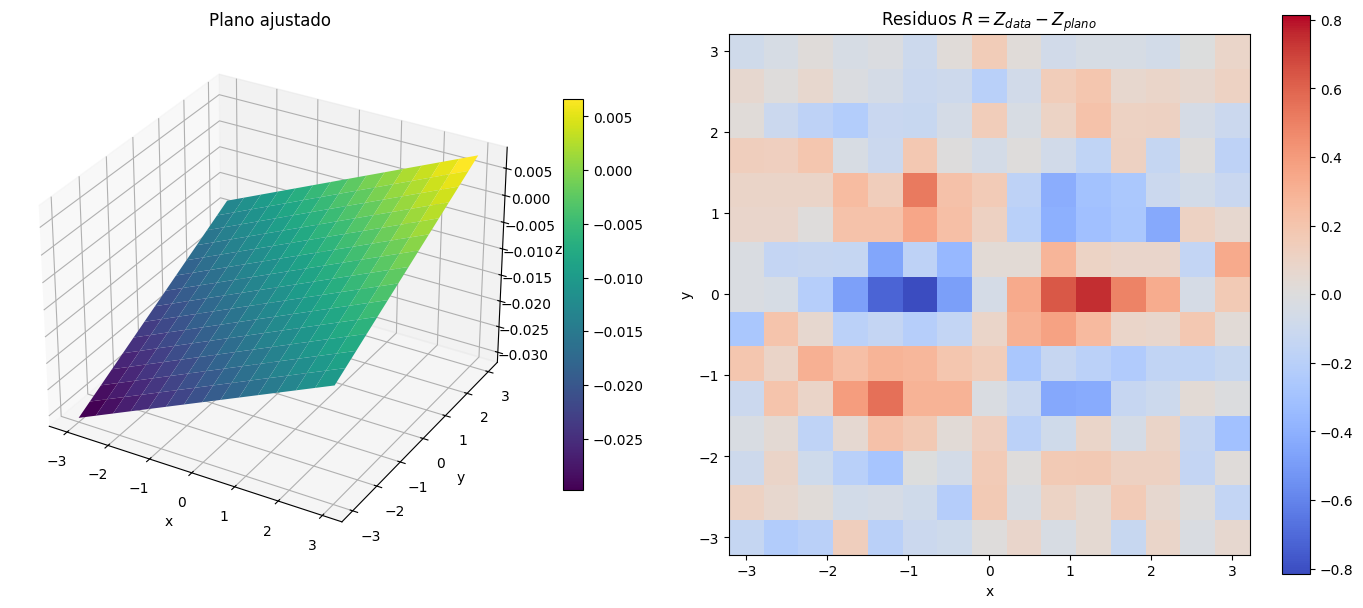

In [6]:
# TODO P3.2: plano ajustado y mapa de residuos
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Evaluar el plano en la malla gruesa
Z_plano = c0 + c1*X_raw + c2*Y_raw

# Residuos
R = Z_data - Z_plano

# Normalización divergente centrada en cero
rmax = np.max(np.abs(R))
norm_res = TwoSlopeNorm(vmin=-rmax, vcenter=0, vmax=rmax)

fig = plt.figure(figsize=(14, 6))

# Panel izquierdo: plano ajustado
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surf1 = ax1.plot_surface(
    X_raw, Y_raw, Z_plano,
    cmap='viridis'
)

ax1.set_title('Plano ajustado')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

fig.colorbar(surf1, ax=ax1, shrink=0.7)

# Panel derecho: mapa de residuos
ax2 = fig.add_subplot(1, 2, 2)

im = ax2.pcolormesh(
    X_raw, Y_raw, R,
    cmap='coolwarm',
    norm=norm_res,
    shading='auto'
)

ax2.set_title('Residuos $R = Z_{data} - Z_{plano}$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')

fig.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [7]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=1.00, omega2=2.60


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

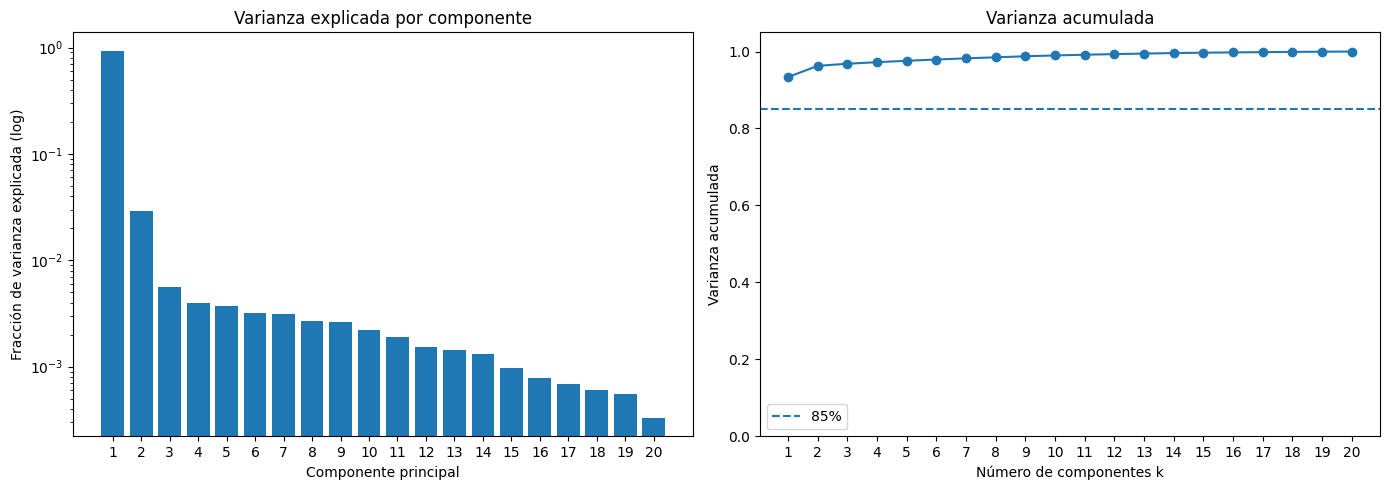

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Centrar las filas: restar la media temporal de cada sensor
X_centered = X - X.mean(axis=1, keepdims=True)

# SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Varianza explicada
var_exp = S**2 / np.sum(S**2)

# Varianza acumulada
var_acum = np.cumsum(var_exp)

# Número de componentes
k = np.arange(1, len(var_exp) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: varianza explicada (escala logarítmica)
axes[0].bar(k, var_exp)
axes[0].set_yscale('log')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Fracción de varianza explicada (log)')
axes[0].set_xticks(k)

# Panel derecho: varianza acumulada
axes[1].plot(k, var_acum, marker='o')
axes[1].axhline(0.85, linestyle='--', label='85%')
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes k')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_xticks(k)
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

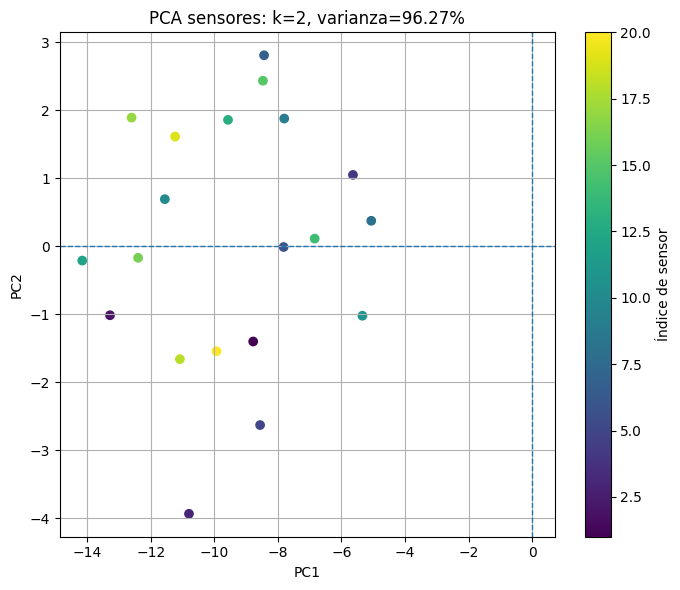

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Elegir k tal que explique más del 89%
k_pca = np.argmax(var_acum > 0.89) + 1

# Por seguridad, limitar a 2 o 3 como pide el enunciado
k_pca = min(max(k_pca, 2), 3)

# Scores de los sensores en los primeros k PCs
# X_centered tiene forma (20, 50)
# Vt[:k_pca].T tiene forma (50, k_pca)
scores = X_centered @ Vt[:k_pca].T

var_capturada = var_acum[k_pca - 1] * 100

sensor_idx = np.arange(1, m + 1)

if k_pca == 2:
    fig, ax = plt.subplots(figsize=(7, 6))

    sc = ax.scatter(
        scores[:, 0],
        scores[:, 1],
        c=sensor_idx,
        cmap='viridis'
    )

    ax.axhline(0, linestyle='--', linewidth=1)
    ax.axvline(0, linestyle='--', linewidth=1)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'PCA sensores: k={k_pca}, varianza={var_capturada:.2f}%')
    ax.grid(True)

    fig.colorbar(sc, ax=ax, label='Índice de sensor')

    plt.tight_layout()
    plt.show()

else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    pares = [
        (0, 1, 'PC1', 'PC2'),
        (0, 2, 'PC1', 'PC3'),
        (1, 2, 'PC2', 'PC3')
    ]

    for ax, (i, j, xlabel, ylabel) in zip(axes, pares):
        sc = ax.scatter(
            scores[:, i],
            scores[:, j],
            c=sensor_idx,
            cmap='viridis'
        )

        for s in range(m):
            ax.text(scores[s, i], scores[s, j], str(s + 1), fontsize=9)

        ax.axhline(0, linestyle='--', linewidth=1)
        ax.axvline(0, linestyle='--', linewidth=1)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True)

    fig.suptitle(f'PCA sensores: k={k_pca}, varianza={var_capturada:.2f}%')

    fig.colorbar(sc, ax=axes, label='Índice de sensor')

    plt.tight_layout()
    plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
